In [6]:
# Install necessary libraries
!pip install scikit-learn scikit-optimize xgboost

In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [13]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-13-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [14]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [15]:
# Custom wrapper for XGBRegressor to fix compatibility with BayesSearchCV
class CustomXGBRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, subsample=1.0, random_state=42):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.subsample = subsample
        self.random_state = random_state
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'n_estimators': self.n_estimators,
            'max_depth': self.max_depth,
            'subsample': self.subsample,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        self.model = XGBRegressor(
            objective='reg:squarederror',
            learning_rate=self.learning_rate,
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            subsample=self.subsample,
            random_state=self.random_state
        )
        return self

# Define the hyperparameter search space for XGBoost
xgb_param_grid = {
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200),  # Integer range for n_estimators
    'max_depth': Integer(3, 5),  # Integer range for max_depth
    'subsample': Real(0.8, 1.0)  # Continuous range for subsample
}

# Initialize the custom XGBoost model
xgb_model = CustomXGBRegressor(random_state=42)

# Initialize BayesSearchCV
xgb_bayes_search = BayesSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=20,  # Number of iterations
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Scoring metric
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit the BayesSearchCV to the training data
xgb_bayes_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_xgb_model = xgb_bayes_search.best_estimator_
xgb_y_pred = best_xgb_model.predict(X_test)

# Print the best hyperparameters
print("Best Hyperparameters for XGBoost:")
print(xgb_bayes_search.best_params_)

Best Hyperparameters for XGBoost:
OrderedDict([('learning_rate', 0.04413925590799911), ('max_depth', 5), ('n_estimators', 200), ('subsample', 0.8)])


In [16]:
# Evaluate the model
xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("XGBoost Model Performance:")
print("Mean Absolute Error:", xgb_mae)
print("Mean Squared Error:", xgb_mse)
print("R-squared:", xgb_r2)

XGBoost Model Performance:
Mean Absolute Error: 7560.42206646244
Mean Squared Error: 599169839.965441
R-squared: 0.9955755944623074


In [17]:
# Cross-validation for XGBoost
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_xgb = cross_validate(best_xgb_model, X_train, y_train, cv=kf, scoring=scoring)
print("XGBoost Cross-Validation Results:")
print("Mean MAE:", -cv_results_xgb['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_xgb['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_xgb['test_r2'].mean())

XGBoost Cross-Validation Results:
Mean MAE: 8106.60317416958
Mean MSE: 724593936.3127692
Mean R2: 0.9948845714049183


In [18]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for XGBoost
xgb_mape = mean_absolute_percentage_error(y_test, xgb_y_pred)
print(f"XGBoost MAPE: {xgb_mape:.2f}%")


XGBoost MAPE: 1.78%


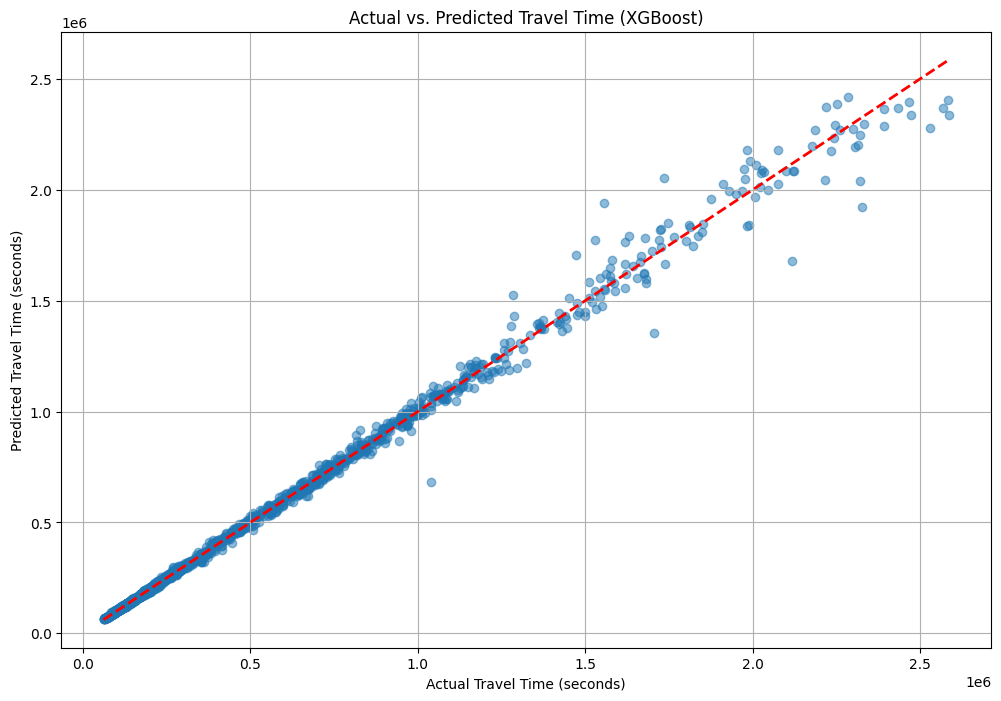

In [19]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, xgb_y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (XGBoost)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

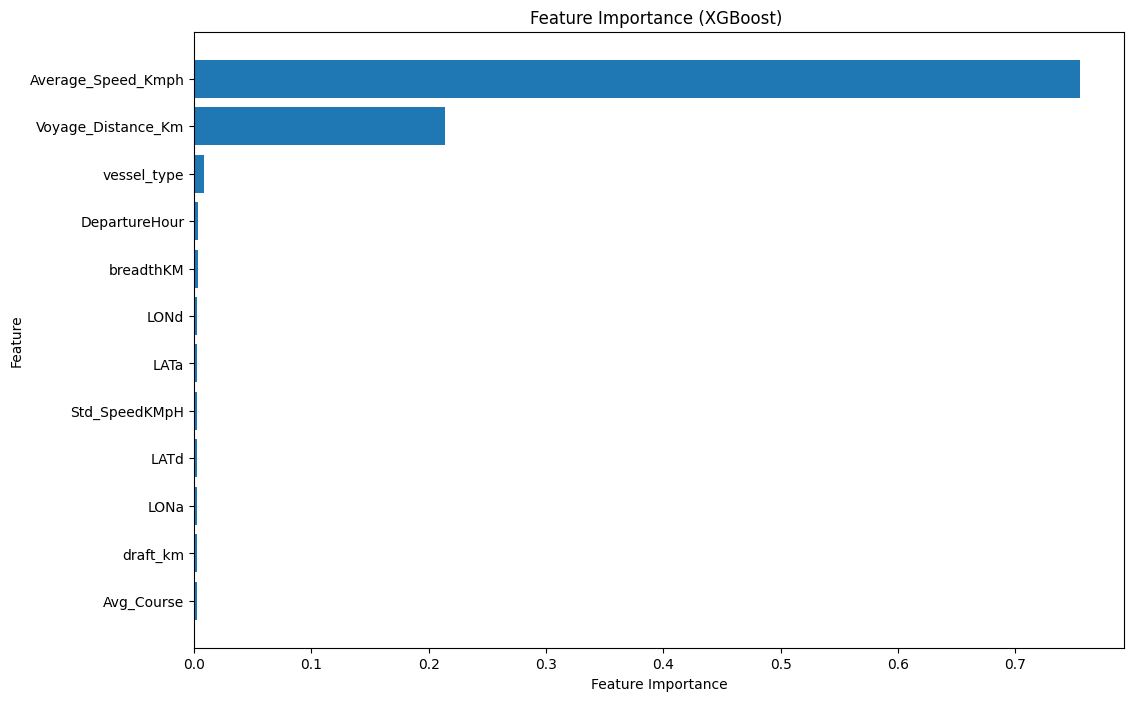

In [27]:
# Feature Importance (XGBoost)
feature_names = numeric_features + ['vessel_type']  # Include only the main features
xgb_importance = best_xgb_model.model.feature_importances_  # Access feature_importances_ from the underlying XGBRegressor model

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(preprocessor.get_feature_names_out()) if name.startswith('cat__vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += xgb_importance[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_importances_aggregated = [importance for i, importance in enumerate(xgb_importance) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_importances_aggregated.append(vessel_type_importance)

# Sort feature importance in ascending order
sorted_idx = np.argsort(feature_importances_aggregated)

# Plot Feature Importance
plt.figure(figsize=(12, 8))
plt.barh(np.array(feature_names)[sorted_idx], np.array(feature_importances_aggregated)[sorted_idx], align='center')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (XGBoost) ')
plt.show()